# TONTOUMA-BOT — Benchmark de traduction Wolof → Français

Compare 4 modèles de traduction sur les métriques **BLEU**, **chrF**, **TER**, **COMET**, plus une évaluation humaine optionnelle.

```
Texte Wolof
   ↓
Modèle de traduction (galsenai / bilalfaye / nllb-general / m2m100)
   ↓
Traduction française
   ↓
Comparaison avec la référence humaine
   ↓
BLEU / chrF / TER / COMET
```

**Point de vigilance** : les 4 modèles n'ont pas la même API (NLLB utilise des codes de langue type `wol_Latn`/`fra_Latn`, M2M100 utilise des codes ISO 2 lettres type `wo`/`fr`) — et **M2M100 ne couvre probablement pas le wolof du tout** (comme Whisper avec `language="wolof"`). Le notebook gère ça avec repli automatique et rapport d'échec explicite plutôt que de planter.

### Installation (une seule fois)

```bash
pip install sacrebleu unbabel-comet transformers torch pandas matplotlib --break-system-packages
```

⚠️ `unbabel-comet` télécharge un modèle de plusieurs centaines de Mo au premier usage — prévoir du temps/espace disque.

In [ ]:
!pip install -U --force-reinstall "protobuf>=5.27.0,<6"
# ici on force la réinstallation de la bibliothèque protobuf pour s'assurer que la version est compatible 
# avec les autres dépendances du projet.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 8.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unbabel-comet 2.2.7 requires protobuf<5.0.0,>=4.24.4, but you have protobuf 5.29.6 which is incompatible.


## 1. Configuration

In [1]:
import time
import warnings
from pathlib import Path

import pandas as pd
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

warnings.filterwarnings("ignore")

MODELES_TRADUCTION = {
    "galsenai-nllb": "galsenai/wolofToFrenchTranslator_nllb",
    "bilalfaye-nllb": "bilalfaye/nllb-200-distilled-600M-wo-fr-en",
    "nllb-general": "facebook/nllb-200-distilled-600M",
    "m2m100": "facebook/m2m100_418M",
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RESULTS_DIR = Path("resultats_traduction")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Device utilisé : {DEVICE.upper()}")
print(f"Modèles à comparer : {list(MODELES_TRADUCTION.keys())}")


Device utilisé : CUDA
Modèles à comparer : ['galsenai-nllb', 'bilalfaye-nllb', 'nllb-general', 'm2m100']


## 2. Chargement des modèles (une seule fois)

Chaque modèle est chargé avec son tokenizer natif, sans supposer qu'ils partagent la même API — c'est justement ce qui varie entre NLLB et M2M100.

In [ ]:
# on suppose que les modeles partagent la meme api caracteristique de traduction, donc on peut les
# charger dans un dictionnaire commun 

#ici on charge les modèles de traduction et leurs tokenizers, en mesurant le temps de chargement
# et le nombre de paramètres pour chaque modèle. Les échecs de chargement sont également enregistrés pour référence.
print("Chargement des modèles de traduction...\n")

tokenizers = {}
modeles = {}
echecs_chargement = {}

for nom, chemin in MODELES_TRADUCTION.items():
    t0 = time.perf_counter()
    try:
        tokenizers[nom] = AutoTokenizer.from_pretrained(chemin)
        modeles[nom] = AutoModelForSeq2SeqLM.from_pretrained(chemin).to(DEVICE)
        temps = time.perf_counter() - t0
        n_params = sum(p.numel() for p in modeles[nom].parameters())
        print(f"   {nom:16s} chargé en {temps:5.1f}s — {n_params/1e6:.0f}M paramètres — {type(tokenizers[nom]).__name__}")
    except Exception as e:
        echecs_chargement[nom] = str(e)
        print(f"   {nom:16s} échec du chargement : {e}")

print(f"\n{len(modeles)}/{len(MODELES_TRADUCTION)} modèles chargés avec succès.")


Chargement des modèles de traduction...

   galsenai-nllb    chargé en  21.7s — 615M paramètres — NllbTokenizerFast
   bilalfaye-nllb   chargé en  11.7s — 615M paramètres — NllbTokenizerFast
   nllb-general     chargé en  12.0s — 615M paramètres — NllbTokenizerFast
   m2m100           chargé en   8.5s — 484M paramètres — M2M100Tokenizer

4/4 modèles chargés avec succès.


## 3. Fonction de traduction unifiée

Gère les différences d'API entre NLLB (`wol_Latn` / `fra_Latn`) et M2M100 (`wo` / `fr`), avec repli automatique si une langue n'est pas supportée par le modèle — exactement comme pour Whisper et le wolof.

In [ ]:
# Codes de langue selon le type de tokenizer

# ici on définit un dictionnaire qui mappe les codes de langue pour les modèles NLLB et M2M100.
    
CODES_LANGUE = {
    "nllb": {"wo": "wol_Latn", "fr": "fra_Latn"},
    "m2m100": {"wo": "wo", "fr": "fr"},
}


def detecter_type_tokenizer(tokenizer):
    nom_classe = type(tokenizer).__name__.lower()
    if "nllb" in nom_classe:
        return "nllb"
    if "m2m100" in nom_classe:
        return "m2m100"
    return "inconnu"


def traduire(nom_modele: str, texte: str, src="wo", tgt="fr", max_new_tokens=128):
    """
    Traduit un texte avec le modèle demandé. Retourne (traduction, erreur).
    Si erreur non None, la traduction est None.
    """
    if nom_modele not in modeles:
        return None, f"Modèle '{nom_modele}' non chargé"

    tokenizer = tokenizers[nom_modele]
    modele = modeles[nom_modele]
    type_tok = detecter_type_tokenizer(tokenizer)

    try:
        if type_tok == "nllb":
            src_code = CODES_LANGUE["nllb"][src]
            tgt_code = CODES_LANGUE["nllb"][tgt]
            tokenizer.src_lang = src_code
            inputs = tokenizer(texte, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
            sortie = modele.generate(
                **inputs,
                forced_bos_token_id=tokenizer.convert_tokens_to_ids(tgt_code),
                max_new_tokens=max_new_tokens,
            )
        elif type_tok == "m2m100":
            src_code = CODES_LANGUE["m2m100"][src]
            tgt_code = CODES_LANGUE["m2m100"][tgt]
            if src_code not in tokenizer.lang_code_to_id:
                return None, f"Langue '{src_code}' non supportée par ce modèle M2M100"
            tokenizer.src_lang = src_code
            inputs = tokenizer(texte, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
            sortie = modele.generate(
                **inputs,
                forced_bos_token_id=tokenizer.get_lang_id(tgt_code),
                max_new_tokens=max_new_tokens,
            )
        else:
            inputs = tokenizer(texte, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
            sortie = modele.generate(**inputs, max_new_tokens=max_new_tokens)

        traduction = tokenizer.batch_decode(sortie, skip_special_tokens=True)[0]
        return traduction, None

    except Exception as e:
        return None, str(e)


print("Fonction de traduction prête (gère NLLB et M2M100 automatiquement).")


Fonction de traduction prête (gère NLLB et M2M100 automatiquement).


## 4. Jeu de test annoté

Phrases wolof avec leur traduction française de référence (vérité terrain pour BLEU/chrF/TER/COMET). **Remplace ces exemples par de vraies paires validées par un locuteur natif** pour un résultat scientifiquement exploitable.

In [ ]:

# Jeu de test permettant d'évaluer les performances des modèles de traduction sur des phrases spécifiques en wolof et
# leurs traductions de référence en français. Chaque entrée contient un identifiant unique, la phrase source en wolof, 
# la traduction de référence en français et le domaine auquel la phrase appartient (orientation, médical, administratif,
# courtoisie).
# Ensuite, on crée un DataFrame pandas pour stocker ces phrases de test et leurs traductions de référence. 
# Cela permettra d'évaluer facilement les performances des modèles de traduction sur ces phrases spécifiques 
 
jeu_test = pd.DataFrame([
    {
        "id": "t001",
        "source_wolof": "Fan la service radiologie ne?",
        "reference_francais": "Où se trouve le service de radiologie ?",
        "domaine": "orientation",
    },
    {
        "id": "t002",
        "source_wolof": "Dama soxla doctoor ndax sama biir dafay metti lool.",
        "reference_francais": "J'ai besoin d'un médecin car j'ai très mal au ventre.",
        "domaine": "medical",
    },
    {
        "id": "t003",
        "source_wolof": "Naka laay def ngir am kayitu juddu?",
        "reference_francais": "Comment faire pour obtenir un acte de naissance ?",
        "domaine": "administratif",
    },
    {
        "id": "t004",
        "source_wolof": "Jërejëf lool ci dimbal bi.",
        "reference_francais": "Merci beaucoup pour l'aide.",
        "domaine": "courtoisie",
    },
    {
        "id": "t005",
        "source_wolof": "Naka laay def ngir am rendez-vous ak specialiste bi?",
        "reference_francais": "Comment prendre rendez-vous avec le spécialiste ?",
        "domaine": "administratif",
    },
])

print(f"{len(jeu_test)} phrases de test.")
display(jeu_test)


5 phrases de test.


,id,source_wolof,reference_francais,domaine
0,t001,Fan la service radiologie ne?,Où se trouve le service de radiologie ?,orientation
1,t002,Dama soxla doctoor ndax sama biir dafay metti ...,J'ai besoin d'un médecin car j'ai très mal au ...,medical
2,t003,Naka laay def ngir am kayitu juddu?,Comment faire pour obtenir un acte de naissance ?,administratif
3,t004,Jërejëf lool ci dimbal bi.,Merci beaucoup pour l'aide.,courtoisie
4,t005,Naka laay def ngir am rendez-vous ak specialis...,Comment prendre rendez-vous avec le spécialiste ?,administratif


## 5. Traduction de chaque phrase par chaque modèle

In [ ]:
# ici on évalue chaque modèle de traduction sur le jeu de test, en mesurant le temps de traduction et en enregistrant 
# les résultats dans un DataFrame pandas.

resultats_traduction = []

for _, ligne in jeu_test.iterrows():
    for nom_modele in MODELES_TRADUCTION:
        t0 = time.perf_counter()
        traduction, erreur = traduire(nom_modele, ligne["source_wolof"], src="wo", tgt="fr")
        temps_ms = (time.perf_counter() - t0) * 1000

        resultats_traduction.append({
            "id": ligne["id"],
            "modele": nom_modele,
            "source_wolof": ligne["source_wolof"],
            "reference_francais": ligne["reference_francais"],
            "traduction": traduction,
            "temps_ms": round(temps_ms, 1),
            "echec": erreur is not None,
            "erreur": erreur,
        })

df_traductions = pd.DataFrame(resultats_traduction)

print("=== Résumé des échecs par modèle ===")
display(df_traductions.groupby("modele")["echec"].sum().rename("nb_echecs"))

print("\n=== Aperçu des traductions ===")
display(df_traductions[["id", "modele", "traduction", "echec"]])


=== Résumé des échecs par modèle ===


,nb_echecs
modele,
bilalfaye-nllb,0
galsenai-nllb,0
m2m100,0
nllb-general,0



=== Aperçu des traductions ===


,id,modele,traduction,echec
0,t001,galsenai-nllb,Où se trouve le service radiologique?,False
1,t001,bilalfaye-nllb,Où est le service de radiologie?,False
2,t001,nllb-general,Quel est le service de radiologie ?,False
3,t001,m2m100,Qu’est-ce que le service de radiologie ?,False
4,t002,galsenai-nllb,J'ai besoin d'un médecin car je souffre énormé...,False
5,t002,bilalfaye-nllb,J'ai besoin d'un médecin parce que mon ventre ...,False
6,t002,nllb-general,J'ai besoin d'un médecin parce que mon estomac...,False
7,t002,m2m100,Dame soxla doctoor s'inscrivant dans le métier...,False
8,t003,galsenai-nllb,Comment puis-je obtenir une attestation de nai...,False
9,t003,bilalfaye-nllb,Comment je peux obtenir un certificat de naiss...,False


## 6. Métriques BLEU, chrF, TER (via `sacrebleu`)

| Métrique | Ce qu'elle mesure | Interprétation |
|---|---|---|
| BLEU | Correspondance des séquences de mots (n-grammes) entre la traduction et la référence | Plus élevé = meilleur |
| chrF | Correspondance au niveau des caractères — plus robuste que BLEU sur les langues morphologiquement riches | Plus élevé = meilleur |
| TER | Nombre de modifications (ajout/suppression/substitution) nécessaires pour transformer la sortie en référence | Plus faible = meilleur |


In [ ]:
# si sacrebleu est installé, on calcule les métriques BLEU, CHRF et TER pour chaque traduction par rapport à la référence.
# la reference est la traduction de référence en français, et la traduction est celle produite par le modèle.
try:
    import sacrebleu
    SACREBLEU_OK = True
except ImportError:
    SACREBLEU_OK = False
    print("sacrebleu non installé -> pip install sacrebleu")


def calculer_bleu_chrf_ter(traduction: str, reference: str):
    if not traduction or pd.isna(traduction):
        return {"bleu": None, "chrf": None, "ter": None}

    bleu = sacrebleu.sentence_bleu(traduction, [reference]).score
    chrf = sacrebleu.sentence_chrf(traduction, [reference]).score
    ter = sacrebleu.sentence_ter(traduction, [reference]).score

    return {"bleu": round(bleu, 2), "chrf": round(chrf, 2), "ter": round(ter, 2)}


if SACREBLEU_OK:
    metriques_ngrammes = df_traductions.apply(
        lambda row: calculer_bleu_chrf_ter(row["traduction"], row["reference_francais"]),
        axis=1,
    )
    df_metriques = pd.DataFrame(list(metriques_ngrammes))
    df_traductions = pd.concat([df_traductions, df_metriques], axis=1)
    display(df_traductions[["id", "modele", "traduction", "bleu", "chrf", "ter"]])
else:
    for col in ["bleu", "chrf", "ter"]:
        df_traductions[col] = None


,id,modele,traduction,bleu,chrf,ter
0,t001,galsenai-nllb,Où se trouve le service radiologique?,55.78,82.01,37.50
1,t001,bilalfaye-nllb,Où est le service de radiologie?,55.78,71.55,50.00
2,t001,nllb-general,Quel est le service de radiologie ?,53.29,71.72,37.50
3,t001,m2m100,Qu’est-ce que le service de radiologie ?,53.29,70.52,37.50
4,t002,galsenai-nllb,J'ai besoin d'un médecin car je souffre énormé...,40.35,64.26,40.00
5,t002,bilalfaye-nllb,J'ai besoin d'un médecin parce que mon ventre ...,26.99,59.10,60.00
6,t002,nllb-general,J'ai besoin d'un médecin parce que mon estomac...,23.46,51.27,70.00
7,t002,m2m100,Dame soxla doctoor s'inscrivant dans le métier...,3.75,15.79,100.00
8,t003,galsenai-nllb,Comment puis-je obtenir une attestation de nai...,20.61,55.14,66.67
9,t003,bilalfaye-nllb,Comment je peux obtenir un certificat de naiss...,23.36,56.37,55.56


In [7]:
pip install sacrebleu


## 7. Métrique COMET (similarité sémantique)

COMET s'appuie sur un modèle entraîné pour juger la qualité de traduction en imitant le jugement humain — souvent plus fiable que BLEU/chrF sur des phrases courtes ou reformulées. Section protégée par `try/except` : si le paquet ou le téléchargement du modèle échoue, le notebook continue avec les autres métriques.

In [8]:
COMET_OK = False
try:
    from comet import download_model, load_from_checkpoint

    print("Téléchargement/chargement du modèle COMET (peut prendre plusieurs minutes la 1ère fois)...")
    chemin_modele_comet = download_model("Unbabel/wmt22-comet-da")
    modele_comet = load_from_checkpoint(chemin_modele_comet)

    donnees_comet = [
        {"src": row["source_wolof"], "mt": row["traduction"], "ref": row["reference_francais"]}
        for _, row in df_traductions.iterrows()
        if row["traduction"] and not pd.isna(row["traduction"])
    ]

    sortie_comet = modele_comet.predict(donnees_comet, batch_size=8, gpu_nb=1 if DEVICE == "cuda" else 0)
    scores_comet = sortie_comet["scores"]

    # Réinjection dans le dataframe (dans l'ordre, en tenant compte des lignes sans traduction)
    idx_valides = df_traductions[df_traductions["traduction"].notna()].index
    df_traductions.loc[idx_valides, "comet"] = [round(s, 4) for s in scores_comet]

    COMET_OK = True
    display(df_traductions[["id", "modele", "traduction", "comet"]])

except Exception as e:
    print(f" COMET non exécuté ({type(e).__name__}: {e})")
    print("   -> pip install unbabel-comet")
    df_traductions["comet"] = None


Téléchargement/chargement du modèle COMET (peut prendre plusieurs minutes la 1ère fois)...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

hparams.yaml:   0%|          | 0.00/567 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

 COMET non exécuté (TypeError: CometModel.predict() got an unexpected keyword argument 'gpu_nb')
   -> pip install unbabel-comet


In [9]:
pip install unbabel-comet

  Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl (295 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


## 8. Évaluation humaine (optionnelle mais recommandée)

BLEU/chrF/TER/COMET sont automatiques mais imparfaits sur des langues peu dotées comme le wolof. Cette cellule permet de noter manuellement chaque traduction sur 3 critères, comme le préconise la dernière ligne du tableau de métriques.

In [ ]:
# Fonction d'évaluation humaine des traductions ici on crée une fonction qui permet à un évaluateur humain de noter 
# manuellement un sous-ensemble de traductions. L'évaluateur est invité à fournir des notes pour la fidélité au sens,
#  la fluidité du français et la compréhensibilité globale. Les notes sont ensuite stockées dans un DataFrame pandas
#  pour une analyse ultérieure. 
def evaluer_humainement(df, echantillon=None):
    """
    Note manuellement un sous-ensemble de traductions.
    echantillon -- nombre de lignes à noter (None = toutes)
    """
    a_noter = df[df["traduction"].notna()]
    if echantillon:
        a_noter = a_noter.sample(min(echantillon, len(a_noter)), random_state=42)

    notes = []
    for _, row in a_noter.iterrows():
        print(f"\n--- {row['id']} | {row['modele']} ---")
        print(f"Wolof     : {row['source_wolof']}")
        print(f"Référence : {row['reference_francais']}")
        print(f"Traduit   : {row['traduction']}")

        fidelite = input("Fidélité au sens (1-5)   : ")
        fluidite = input("Fluidité du français (1-5) : ")
        comprehension = input("Compréhensible globalement (1-5) : ")

        notes.append({
            "id": row["id"], "modele": row["modele"],
            "fidelite": int(fidelite) if fidelite else None,
            "fluidite": int(fluidite) if fluidite else None,
            "comprehension": int(comprehension) if comprehension else None,
        })

    return pd.DataFrame(notes)


# Décommente pour lancer une session de notation manuelle (interactive) :
# df_eval_humaine = evaluer_humainement(df_traductions, echantillon=5)
print("Fonction prête : evaluer_humainement(df_traductions, echantillon=5)")


Fonction prête : evaluer_humainement(df_traductions, echantillon=5)


## 9. Agrégation des résultats et sauvegarde

In [11]:
chemin_detail = RESULTS_DIR / "traduction_resultats_detailles.csv"
df_traductions.to_csv(chemin_detail, index=False)
print(f"Résultats détaillés sauvegardés : {chemin_detail}")

colonnes_agg = [c for c in ["bleu", "chrf", "ter", "comet", "temps_ms"] if c in df_traductions.columns]
df_resume = df_traductions.groupby("modele")[colonnes_agg].mean(numeric_only=True).round(3)
df_resume["taux_echec"] = df_traductions.groupby("modele")["echec"].mean().round(3)

chemin_resume = RESULTS_DIR / "traduction_resume.csv"
df_resume.to_csv(chemin_resume)
print(f"Résumé sauvegardé : {chemin_resume}\n")

display(df_resume)


Résultats détaillés sauvegardés : resultats_traduction/traduction_resultats_detailles.csv
Résumé sauvegardé : resultats_traduction/traduction_resume.csv



,bleu,chrf,ter,temps_ms,taux_echec
modele,,,,,
bilalfaye-nllb,49.448,72.606,50.254,212.22,0.0
galsenai-nllb,49.660,71.408,45.976,403.32,0.0
m2m100,17.416,32.488,77.342,368.58,0.0
nllb-general,24.546,47.074,97.452,260.64,0.0


## 10. Graphiques comparatifs

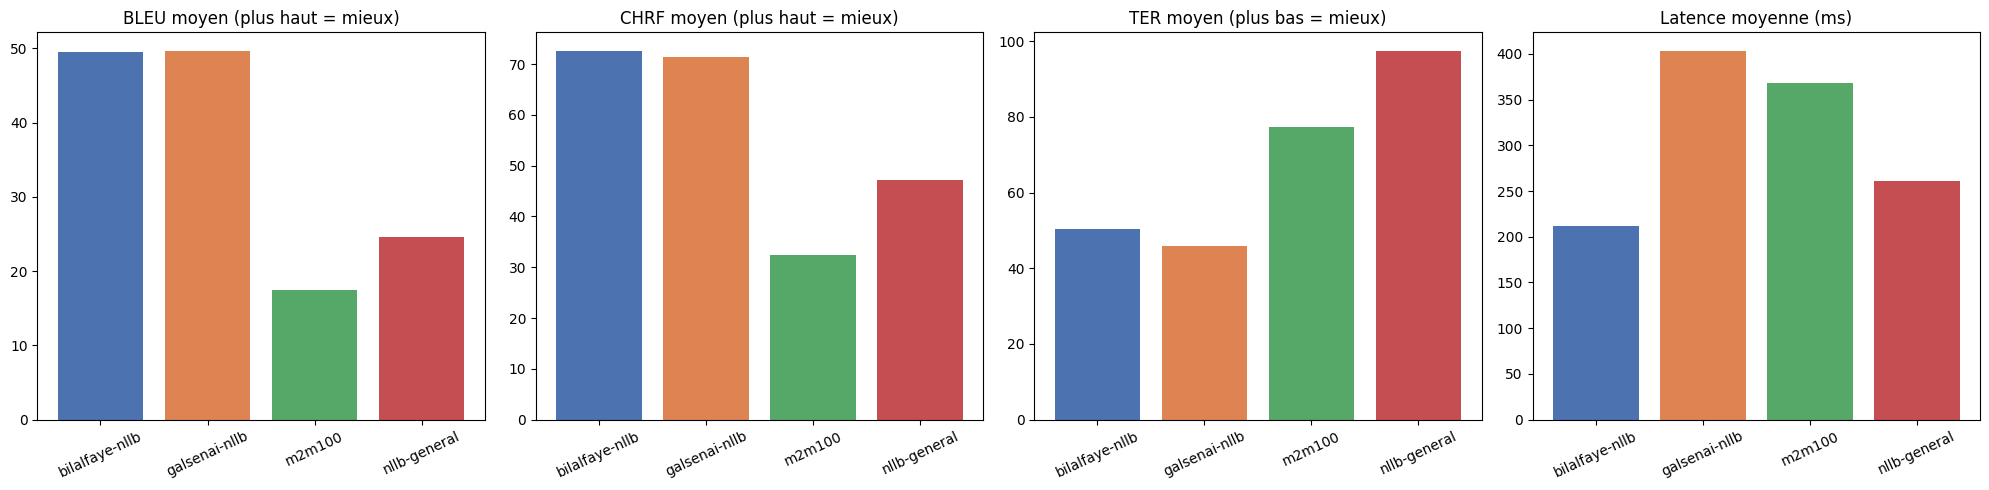

Graphiques sauvegardés : resultats_traduction/graphiques_traduction.png


In [12]:
import matplotlib.pyplot as plt

metriques_a_tracer = [c for c in ["bleu", "chrf", "comet"] if c in df_resume.columns and df_resume[c].notna().any()]
n = len(metriques_a_tracer) + 2  # + TER + latence

fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

couleurs = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, metrique in enumerate(metriques_a_tracer):
    axes[i].bar(df_resume.index, df_resume[metrique], color=couleurs[:len(df_resume)])
    axes[i].set_title(f"{metrique.upper()} moyen (plus haut = mieux)")
    axes[i].tick_params(axis="x", rotation=25)

idx_ter = len(metriques_a_tracer)
if "ter" in df_resume.columns and df_resume["ter"].notna().any():
    axes[idx_ter].bar(df_resume.index, df_resume["ter"], color=couleurs[:len(df_resume)])
    axes[idx_ter].set_title("TER moyen (plus bas = mieux)")
    axes[idx_ter].tick_params(axis="x", rotation=25)

axes[-1].bar(df_resume.index, df_resume["temps_ms"], color=couleurs[:len(df_resume)])
axes[-1].set_title("Latence moyenne (ms)")
axes[-1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "graphiques_traduction.png", dpi=150)
plt.show()

print(f"Graphiques sauvegardés : {RESULTS_DIR / 'graphiques_traduction.png'}")


## 11. Bilan : meilleur modèle par métrique

In [13]:
print("=== Meilleur modèle par métrique ===\n")

if "bleu" in df_resume.columns and df_resume["bleu"].notna().any():
    print(f"🏆 Meilleur BLEU  : {df_resume['bleu'].idxmax()} ({df_resume['bleu'].max():.2f})")
if "chrf" in df_resume.columns and df_resume["chrf"].notna().any():
    print(f"🏆 Meilleur chrF  : {df_resume['chrf'].idxmax()} ({df_resume['chrf'].max():.2f})")
if "ter" in df_resume.columns and df_resume["ter"].notna().any():
    print(f"🏆 Meilleur TER   : {df_resume['ter'].idxmin()} ({df_resume['ter'].min():.2f}, plus bas = mieux)")
if "comet" in df_resume.columns and df_resume["comet"].notna().any():
    print(f"🏆 Meilleur COMET : {df_resume['comet'].idxmax()} ({df_resume['comet'].max():.3f})")

print(f"\n⚡ Modèle le plus rapide : {df_resume['temps_ms'].idxmin()} ({df_resume['temps_ms'].min():.0f} ms)")

if echecs_chargement:
    print(f"\n⚠️  Modèles n'ayant pas pu être chargés : {list(echecs_chargement.keys())}")

taux_echec_traduction = df_traductions.groupby('modele')['echec'].mean()
modeles_incomplets = taux_echec_traduction[taux_echec_traduction > 0]
if not modeles_incomplets.empty:
    print(f"\n⚠️  Modèles avec échecs de traduction (langue probablement non supportée) :")
    for nom, taux in modeles_incomplets.items():
        print(f"   {nom} : {taux*100:.0f}% d'échec")


=== Meilleur modèle par métrique ===

🏆 Meilleur BLEU  : galsenai-nllb (49.66)
🏆 Meilleur chrF  : bilalfaye-nllb (72.61)
🏆 Meilleur TER   : galsenai-nllb (45.98, plus bas = mieux)

⚡ Modèle le plus rapide : bilalfaye-nllb (212 ms)


## 12. Sauvegarde des modèles

In [14]:
print("Sauvegarde des modèles...")

for nom_modele, modele_obj in modeles.items():
    chemin_modele = RESULTS_DIR / f"modele_{nom_modele}.pt"
    torch.save(modele_obj.state_dict(), chemin_modele)
    print(f"   Modèle '{nom_modele}' sauvegardé : {chemin_modele}")

print("Sauvegarde des tokenizers...")

for nom_tokenizer, tokenizer_obj in tokenizers.items():
    chemin_tokenizer = RESULTS_DIR / f"tokenizer_{nom_tokenizer}"
    tokenizer_obj.save_pretrained(chemin_tokenizer)
    print(f"   Tokenizer '{nom_tokenizer}' sauvegardé : {chemin_tokenizer}")

Sauvegarde des modèles...
   Modèle 'galsenai-nllb' sauvegardé : resultats_traduction/modele_galsenai-nllb.pt
   Modèle 'bilalfaye-nllb' sauvegardé : resultats_traduction/modele_bilalfaye-nllb.pt


KeyboardInterrupt: 